In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
def load_direct_data(en, cont, alg, name):
    path = f"./Data/generation_ex/{en}/{cont}/{alg}/{name}"
    json_files = list(Path(path).glob("*.json"))
    print(f"Found {len(json_files)} files!")
    with open(json_files[0], "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def extract_fitness_values(file_content):
    df = pd.DataFrame(file_content["fitness"]).reset_index(names="seed").melt(
        id_vars="seed", 
        var_name="ng", 
        value_name="population"
    )
    df["ng"] = df["ng"].astype(int)
    df["max_fit"] = df["population"].apply(lambda x: np.max(list(map(lambda y: y[0], x))))
    df["avg_fit"] = df["population"].apply(lambda x: np.mean(list(map(lambda y: y[0], x))))
    df["median_fit"] = df["population"].apply(lambda x: np.median(list(map(lambda y: y[0], x))))
    df["min_fit"] = df["population"].apply(lambda x: np.min(list(map(lambda y: y[0], x))))
    df["std_fit"] = df["population"].apply(lambda x: np.std(list(map(lambda y: y[0], x))))
    return df

In [ ]:
file_content = load_direct_data("lunarlander", "add_novelty", "lambda", "fourth_try")
df = extract_fitness_values(file_content)

Found 1 files!


In [ ]:


df

,seed,ng,population,max_fit,avg_fit,median_fit,min_fit,std_fit
0,101,35,"[[[-408.523974832645], [-0.18523365259170532, ...",-408.523975,-408.523975,-408.523975,-408.523975,0.000000e+00
1,105,35,"[[[77.65085271021105], [-0.155869460105896, -0...",77.650853,77.650853,77.650853,77.650853,1.421085e-14
2,104,35,"[[[-30.19612852137064], [0.07173797488212585, ...",-30.196129,-30.196129,-30.196129,-30.196129,0.000000e+00
3,103,35,"[[[25.37880515173197], [0.17300522327423096, -...",25.378805,25.378805,25.378805,25.378805,0.000000e+00
4,102,35,"[[[26.00680963004775], [0.07231113314628601, -...",26.006810,26.006800,26.006800,26.006791,9.562445e-06
5,101,10,"[[[-190.40720539905033], [-0.40209259986877444...",-105.610707,-221.298732,-190.407205,-521.330602,9.487256e+01
6,105,10,"[[[-345.4452820396338], [-0.07675724029541016,...",65.875459,-164.115792,-173.757032,-439.690155,9.167465e+01
7,104,10,"[[[-30.19612852137064], [0.07173797488212585, ...",-30.196129,-30.196129,-30.196129,-30.196129,0.000000e+00
8,103,10,"[[[-46.731552914238385], [0.05960925817489624,...",78.038768,-49.310960,-46.731553,-192.062597,3.430463e+01
9,102,10,"[[[21.01434223453461], [0.05156295895576477, -...",52.761730,-52.317990,3.258547,-291.732918,9.513589e+01


/tmp/ipykernel_639822/3201232588.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ploted_df = ploted_df.groupby("ng").mean().reset_index()


<Axes: xlabel='ng', ylabel='value'>

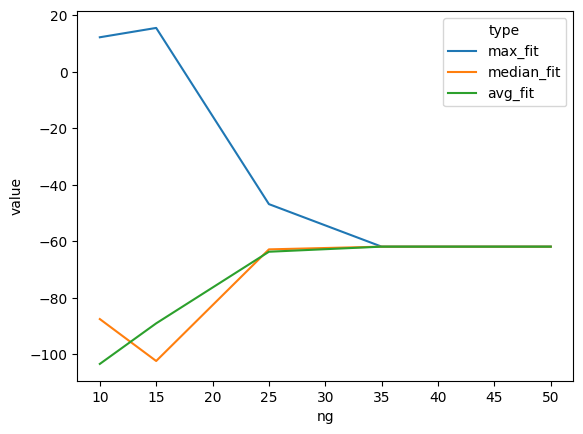

In [ ]:
import seaborn as sns
df = df.sort_values("ng")
ploted_df = df[["ng", "seed", "max_fit", "median_fit", "avg_fit"]]
ploted_df = ploted_df.groupby("ng").mean().reset_index()
ploted_df = ploted_df.melt(
        id_vars="ng", 
        var_name="type", 
        value_name="value"
    )
sns.lineplot(data=ploted_df, x="ng", y="value", hue="type")